# FakeBreaker
## News Classification: Real, Fake or AI.
### [CM3070] Final Project, Adapted from the NLP fake news detection template.

## 1. Project Setup
Let's start with importing the necessary libraries and the datasets, the WELFake Kaggle dataset and the GPT2-output dataset.

### 1.1 Importing Libraries and Tools

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt # Plotting properties
import seaborn as sns
# Set style for seaborn for better readability
sns.set(style="whitegrid")
from wordcloud import WordCloud
import nltk

# Show all matplotlib graphs inline
%matplotlib inline

In [4]:
!pip install gdown  # Install gdown for google drive files

In [5]:
import gdown

### 1.2 Import GPT2-output Dataset

In [7]:
import os
import sys
import requests
from tqdm import tqdm
import re

In [8]:
# subdir = 'data'
# if not os.path.exists(subdir):
#     os.makedirs(subdir)
# subdir = subdir.replace('\\','/') # needed for Windows


# # Just downloading outputs from strongest version (xl-1542M)

# # The dataset contains train, valid and test sets, but the number of samples
# # is so large that we only need the training set (250,000 samples)
# filename = 'xl-1542M-k40.train.jsonl'
# r = requests.get("https://openaipublic.azureedge.net/gpt-2/output-dataset/v1/" + filename, stream=True)

# with open(os.path.join(subdir, filename), 'wb') as f:
#     file_size = int(r.headers["content-length"])
#     chunk_size = 1000
#     with tqdm(ncols=100, desc="Fetching " + filename, total=file_size, unit_scale=True) as pbar:
#         # 1k for chunk_size, since Ethernet packet size is around 1500 bytes
#         for chunk in r.iter_content(chunk_size=chunk_size):
#             f.write(chunk)
#             pbar.update(chunk_size)

In [9]:
# ai_df = pd.read_json('data/xl-1542M-k40.train.jsonl', lines=True)

In [10]:
# ai_df.to_csv('data/gpt2_output.csv', index=False)

In [11]:
# Import the GPT2 dataset
# gpt2_df = pd.read_csv('data/gpt2_output.csv')

In [12]:
# Download dataset from Google Drive
file_id = "1eFoFTi0GmWX_fMJtI9MWzuh-G5MLVFd0"
destination = "g_data/gpt2_output.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1eFoFTi0GmWX_fMJtI9MWzuh-G5MLVFd0
From (redirected): https://drive.google.com/uc?id=1eFoFTi0GmWX_fMJtI9MWzuh-G5MLVFd0&confirm=t&uuid=03ddd84b-234e-4c3f-93d0-f206e02f42f7
To: /Users/yassu/Desktop/FP_Fake_News/g_data/gpt2_output.csv
100%|██████████████████████████████████████████████| 731M/731M [01:17<00:00, 9.46MB/s]


'g_data/gpt2_output.csv'

In [13]:
# Load the dataset into a DataFrame
gpt2_df = pd.read_csv(destination)

In [14]:
# Confirm length is correct (250,000 expected)
print("Number of AI text articles: " + str(len(gpt2_df)))

Number of AI text articles: 250000


In [15]:
gpt2_df.head()

,id,text,length,ended
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True
1,2,The latest edition of the German Football Hall...,715,True
2,3,"Dangerous animals, especially snakes, in a car...",1024,False
3,4,I started my first MLP story way back in 2014 ...,1024,False
4,5,This article is a disambiguation page for The ...,84,True


In [16]:
# Printing first output
gpt2_df.iloc[0, 1]

'Cops will have to take "extreme care" to avoid jail-breaking the latest iPhones as the US government will fine manufacturers for breaking its digital security.\n\nApple has been criticised for designing and releasing its latest smartphone without any security measures.\n\nApple has defended the iPhone 6 for carrying out some of its advanced security measures, but will be fined if it continues to fail that test.\n\nThe Federal Communications Commission and FBI will be allowed to fine companies as much as $25,000 (£17,800) for not patching bugs after they are announced.\n\nThe FCC, under a new ruling from president Obama , will allow fines of $1,500 per device over the same "bug bounty".\n\nThere have been multiple hacks into iPhone 6 smartphones this year in the wake of the 2013 revelation that the device could be unlocked with a passcode lock.\n\nHowever, security experts have criticised Apple\'s software and device for not patching its bugs to prevent them becoming the latest weapon 

### 1.3 Import the WELFake Dataset

In [18]:
# Import the WELFake dataset
# welfake_df = pd.read_csv('data/welfake_dataset.csv')

In [19]:
# Download dataset from Google Drive
file_id = "1xs7EhkRBLfgZBqfOH_vKSU2KdYZzNuDt"
destination = "g_data/welfake_dataset.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xs7EhkRBLfgZBqfOH_vKSU2KdYZzNuDt
From (redirected): https://drive.google.com/uc?id=1xs7EhkRBLfgZBqfOH_vKSU2KdYZzNuDt&confirm=t&uuid=a1b83aa6-275d-45aa-80f4-063c980015c6
To: /Users/yassu/Desktop/FP_Fake_News/g_data/welfake_dataset.csv
100%|██████████████████████████████████████████████| 245M/245M [00:26<00:00, 9.31MB/s]


'g_data/welfake_dataset.csv'

In [20]:
# Load the dataset into a DataFrame
welfake_df = pd.read_csv(destination)

In [21]:
welfake_df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [22]:
welfake_df.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


## 2. Data Pre-processing and Cleaning
After all the datasets have been imported, we will go into pre-processing and cleaning them.

In [24]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
# Downloading NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For WordNet
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /Users/yassu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/yassu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/yassu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/yassu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/yassu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /Users/yassu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/yassu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data] 

True

### 2.1 Pre-processing the 'WELFake' Kaggle Dataset

In [26]:
welfake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [27]:
welfake_df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [28]:
# Mapping 0 and 1 to 'fake' and 'real' labels
welfake_df['label'] = welfake_df['label'].map({0: 'fake', 1: 'real'})

In [29]:
# Drop unnecessary columns
welfake_df.drop(['Unnamed: 0', 'title'], axis=1, inplace=True)

In [30]:
welfake_df.isnull().sum()

text     39
label     0
dtype: int64

In [31]:
# Dropping duplicates
welfake_df = welfake_df.drop_duplicates(subset='text').reset_index(drop=True)

In [32]:
# Dropping null values
welfake_df = welfake_df.dropna(subset=['text'])

In [33]:
welfake_df.isnull().sum()

text     0
label    0
dtype: int64

In [34]:
welfake_df.head()

,text,label
0,No comment is expected from Barack Obama Membe...,real
1,Did they post their votes for Hillary already?,real
2,"Now, most of the demonstrators gathered last ...",real
3,A dozen politically active pastors came here f...,fake
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",real


In [35]:
welfake_df.tail()

,text,label
62714,An email released by WikiLeaks on Sunday appea...,real
62715,WASHINGTON (Reuters) - Hackers believed to be ...,fake
62716,"You know, because in fantasyland Republicans n...",real
62717,Migrants Refuse To Leave Train At Refugee Camp...,fake
62718,MEXICO CITY (Reuters) - Donald Trump’s combati...,fake


### 2.2 Implementing a function to clean the text

In [37]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Improve lemmatization with proper POS tagging
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def clean_text(text):
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove special characters and numbers, keep only letters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text using nltk.word_tokenize()
    words = word_tokenize(text)
    # Remove stopwords and lemmatize each word with correct POS tagging
    words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words if word not in stop_words]
    # Rejoin the words into a single string
    return " ".join(words)

In [38]:
# Example use
sample_text = "This is an example sentence with some URLs https://example.com and numbers 123!"
print(clean_text(sample_text))

example sentence url number


In [39]:
# Apply clean_text function to clean the dataframe
welfake_df['cleaned_text'] = welfake_df['text'].apply(clean_text)

In [40]:
welfake_df.head()

,text,label,cleaned_text
0,No comment is expected from Barack Obama Membe...,real,comment expect barack obama member fyf fukyofl...
1,Did they post their votes for Hillary already?,real,post vote hillary already
2,"Now, most of the demonstrators gathered last ...",real,demonstrator gather last night exercise consti...
3,A dozen politically active pastors came here f...,fake,dozen politically active pastor come private d...
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",real,r sarmat missile dubbed satan replace s fly mi...


In [41]:
welfake_df.tail()

,text,label,cleaned_text
62714,An email released by WikiLeaks on Sunday appea...,real,email release wikileaks sunday appear show for...
62715,WASHINGTON (Reuters) - Hackers believed to be ...,fake,washington reuters hacker believe work russian...
62716,"You know, because in fantasyland Republicans n...",real,know fantasyland republican never question cit...
62717,Migrants Refuse To Leave Train At Refugee Camp...,fake,migrant refuse leave train refugee camp hungar...
62718,MEXICO CITY (Reuters) - Donald Trump’s combati...,fake,mexico city reuters donald trump combative sty...


In [42]:
welfake_df = welfake_df[["cleaned_text", "label"]]

In [43]:
welfake_df = welfake_df.rename(columns={"cleaned_text": "text"})

In [44]:
welfake_df.head()

,text,label
0,comment expect barack obama member fyf fukyofl...,real
1,post vote hillary already,real
2,demonstrator gather last night exercise consti...,real
3,dozen politically active pastor come private d...,fake
4,r sarmat missile dubbed satan replace s fly mi...,real


### 2.3 Pre-processing the GPT2-output Dataset

In [46]:
# Creating a label column
gpt2_df["label"] = "AI-generated"

In [47]:
gpt2_df.head()

,id,text,length,ended,label
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True,AI-generated
1,2,The latest edition of the German Football Hall...,715,True,AI-generated
2,3,"Dangerous animals, especially snakes, in a car...",1024,False,AI-generated
3,4,I started my first MLP story way back in 2014 ...,1024,False,AI-generated
4,5,This article is a disambiguation page for The ...,84,True,AI-generated


In [48]:
# Dropping unnecessary columns
gpt2_df.drop(['id', 'length', 'ended'], axis=1, inplace=True)

In [49]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [50]:
# Remove duplicates and handle missing values
gpt2_df.drop_duplicates(subset="text", inplace=True)
gpt2_df.dropna(subset=["text"], inplace=True)

In [51]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [52]:
# Apply clean_text function to clean the dataframe
gpt2_df['text'] = gpt2_df['text'].apply(clean_text)

In [53]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking late ...,AI-generated
1,late edition german football hall fame ballot ...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,start first mlp story way back joke well reall...,AI-generated
4,article disambiguation page big apple follow l...,AI-generated


### 2.4 Checking All the Datasets

In [55]:
welfake_df.head()

,text,label
0,comment expect barack obama member fyf fukyofl...,real
1,post vote hillary already,real
2,demonstrator gather last night exercise consti...,real
3,dozen politically active pastor come private d...,fake
4,r sarmat missile dubbed satan replace s fly mi...,real


In [56]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking late ...,AI-generated
1,late edition german football hall fame ballot ...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,start first mlp story way back joke well reall...,AI-generated
4,article disambiguation page big apple follow l...,AI-generated


In [57]:
welfake_df.tail()

,text,label
62714,email release wikileaks sunday appear show for...,real
62715,washington reuters hacker believe work russian...,fake
62716,know fantasyland republican never question cit...,real
62717,migrant refuse leave train refugee camp hungar...,fake
62718,mexico city reuters donald trump combative sty...,fake


In [58]:
gpt2_df.tail()

,text,label
249995,lot thing dont like job cooped office long hou...,AI-generated
249996,year unprecedented public outcry use water pun...,AI-generated
249997,battle english scot english victory flodden ki...,AI-generated
249998,kurt rambis new head coach knicks kurt rambis ...,AI-generated
249999,leader need thats differ new president united ...,AI-generated


In [59]:
# saving all cleaned dataframes to CSV files.
welfake_df.to_csv('processed_data/welfake.csv', index=False)
gpt2_df.to_csv('processed_data/gpt2.csv', index=False)

In [60]:
welfake_df["label"].value_counts()

label
fake    34620
real    28098
Name: count, dtype: int64

In [61]:
gpt2_df["label"].value_counts()

label
AI-generated    249796
Name: count, dtype: int64

### 2.4 Balancing The Data

In [63]:
# Merge datasets
merged_df = pd.concat([gpt2_df, welfake_df])

In [64]:
merged_df.head()

,text,label
0,cop take extreme care avoid jailbreaking late ...,AI-generated
1,late edition german football hall fame ballot ...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,start first mlp story way back joke well reall...,AI-generated
4,article disambiguation page big apple follow l...,AI-generated


In [65]:
merged_df.tail()

,text,label
62714,email release wikileaks sunday appear show for...,real
62715,washington reuters hacker believe work russian...,fake
62716,know fantasyland republican never question cit...,real
62717,migrant refuse leave train refugee camp hungar...,fake
62718,mexico city reuters donald trump combative sty...,fake


In [66]:
# Check for duplicates in text and label columns
duplicates = merged_df.duplicated(subset=['text', 'label'])
print(f"Number of duplicate entries: {duplicates.sum()}")

Number of duplicate entries: 576


In [67]:
# Dropping duplicates
merged_df = merged_df.drop_duplicates(subset=['text', 'label'], keep='first')

In [68]:
print(merged_df['label'].value_counts())

label
AI-generated    249546
fake             34493
real             27899
Name: count, dtype: int64


In [69]:
from sklearn.utils import resample

# Separate classes
fake_news = merged_df[merged_df['label'] == 'fake']
real_news = merged_df[merged_df['label'] == 'real']
ai_news = merged_df[merged_df['label'] == 'AI-generated']

# Ensure balanced class distribution
min_count = min(len(fake_news), len(real_news), len(ai_news))

fake_news = resample(fake_news, replace=False, n_samples=min_count, random_state=42)
real_news = resample(real_news, replace=False, n_samples=min_count, random_state=42)
ai_news = resample(ai_news, replace=False, n_samples=min_count, random_state=42)

balanced_df = pd.concat([fake_news, real_news, ai_news], ignore_index=True)

### 2.5 Shuffling the dataset to mix samples from different sources.

In [71]:
# Shuffle the dataset to ensure randomness
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [72]:
balanced_df['label'].value_counts()

label
real            27899
AI-generated    27899
fake            27899
Name: count, dtype: int64

In [73]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83697 entries, 0 to 83696
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    83697 non-null  object
 1   label   83697 non-null  object
dtypes: object(2)
memory usage: 1.3+ MB


In [74]:
balanced_df.shape

(83697, 2)

In [75]:
balanced_df.isnull().sum()

text     0
label    0
dtype: int64

In [76]:
balanced_df.tail()

,text,label
83692,washington reuters president barack obamas spe...,fake
83693,widely believe gop vice presidential nominee g...,real
83694,excite weekend many folk spent much time talk ...,AI-generated
83695,presidential contender beg iowa supporter get ...,fake
83696,democratic presidential candidate hillary clin...,fake


## 3. Exploratory Data Analysis (EDA)

In [78]:
# Get basic info (data types, non-null counts)
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83697 entries, 0 to 83696
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    83697 non-null  object
 1   label   83697 non-null  object
dtypes: object(2)
memory usage: 1.3+ MB


In [79]:
# Get statistical summary for numerical columns
balanced_df.describe()

,text,label
count,83697,83697
unique,83696,3
top,,real
freq,2,27899


In [80]:
# Check for null values
balanced_df.isnull().sum()

text     0
label    0
dtype: int64

### 3.1 Label & Text Length Distribution

In [82]:
# Calculate distribution ratio
label_ratios = balanced_df['label'].value_counts(normalize=True) * 100  # Convert to percentage
print(label_ratios)

label
real            33.333333
AI-generated    33.333333
fake            33.333333
Name: proportion, dtype: float64


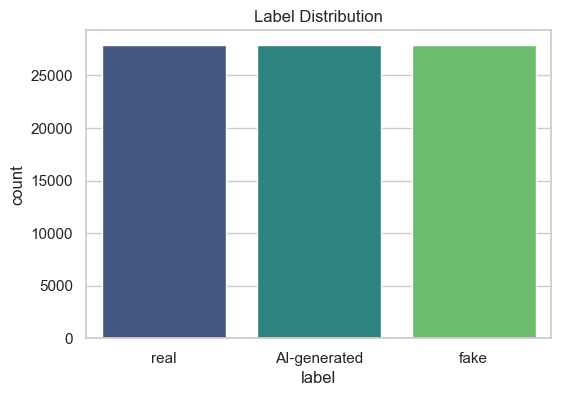

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=balanced_df, x='label', hue='label', palette="viridis")
plt.title('Label Distribution')
plt.show()

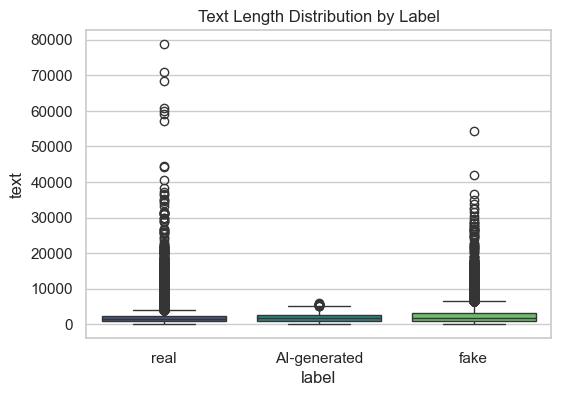

In [84]:
# Plot text length vs label
plt.figure(figsize=(6, 4))
sns.boxplot(data=balanced_df, x='label',hue='label', palette="viridis", y=balanced_df['text'].apply(len))
plt.title('Text Length Distribution by Label')
plt.show()

### 3.2 WordClouds: Most Frequent Words in each Label

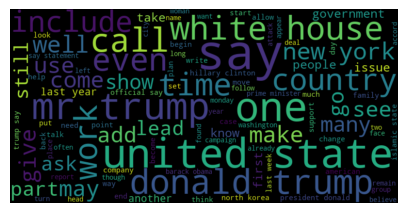

In [86]:
from wordcloud import WordCloud

wordcloud_text = ''.join(balanced_df[balanced_df['label']=='fake']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

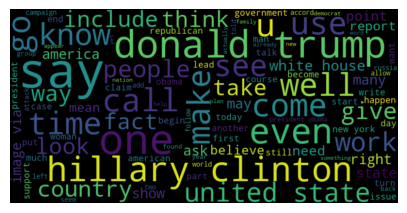

In [87]:
wordcloud_text = ''.join(balanced_df[balanced_df['label']=='real']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

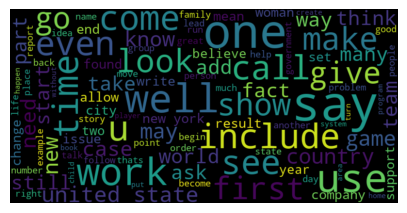

In [88]:
wordcloud_text = ''.join(balanced_df[balanced_df['label']=='AI-generated']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 3.3 N-gram Analysis (Bigram/Trigram Frequency)

In [90]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [91]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [92]:
def get_top_ngrams(corpus, n=None, ngram_range=(2,2), max_features=50000):
    """Extracts the top N most common n-grams from the corpus"""
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=max_features)
    # Transform the corpus into a document-term matrix
    X = vectorizer.fit_transform(corpus)
    # Sum column-wise without converting to a dense array
    ngram_counts = X.sum(axis=0).A1  
    ngram_freq = list(zip(vectorizer.get_feature_names_out(), ngram_counts))
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)[:n]
    
    return ngram_freq

In [93]:
# Filter dataset by labels and convert to lists
real_news = balanced_df[balanced_df['label'] == 'real']['text'].tolist()
fake_news = balanced_df[balanced_df['label'] == 'fake']['text'].tolist()
ai_generated = balanced_df[balanced_df['label'] == 'AI-generated']['text'].tolist()

# Get the top 20 bigrams
real_bigrams = get_top_ngrams(real_news, n=20, ngram_range=(2,2))
fake_bigrams = get_top_ngrams(fake_news, n=20, ngram_range=(2,2))
ai_bigrams = get_top_ngrams(ai_generated, n=20, ngram_range=(2,2))

# Get the top 20 trigrams
real_trigrams = get_top_ngrams(real_news, n=20, ngram_range=(3,3))
fake_trigrams = get_top_ngrams(fake_news, n=20, ngram_range=(3,3))
ai_trigrams = get_top_ngrams(ai_generated, n=20, ngram_range=(3,3))

In [94]:
def plot_ngrams(ngram_freq, title):
    ngrams, counts = zip(*ngram_freq)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), hue=list(counts), y=list(ngrams), palette="viridis")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("N-grams")
    plt.show()

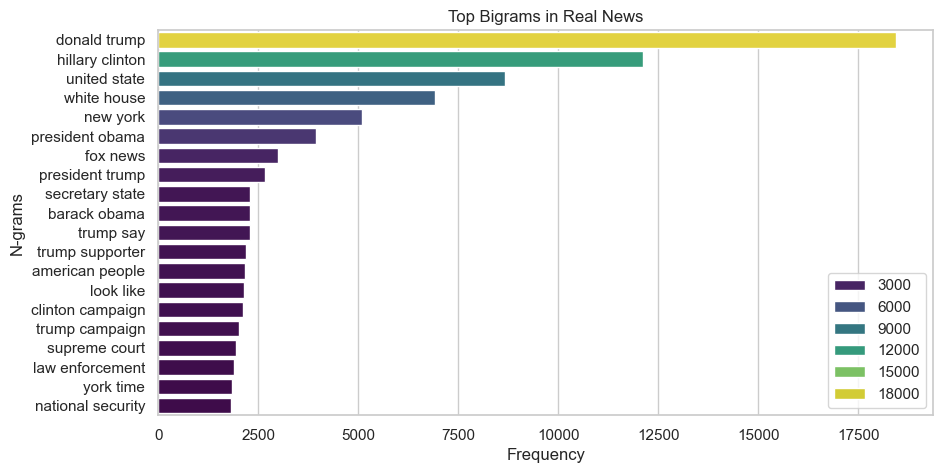

In [95]:
plot_ngrams(real_bigrams, "Top Bigrams in Real News")

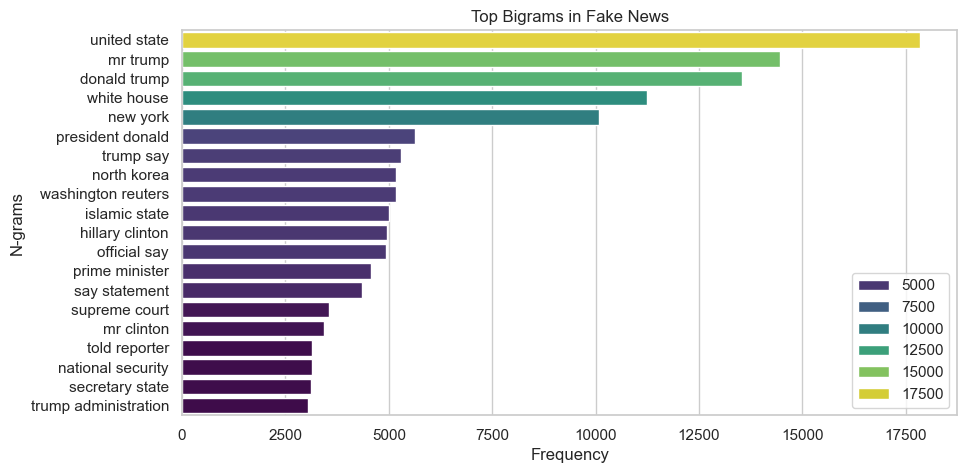

In [96]:
plot_ngrams(fake_bigrams, "Top Bigrams in Fake News")

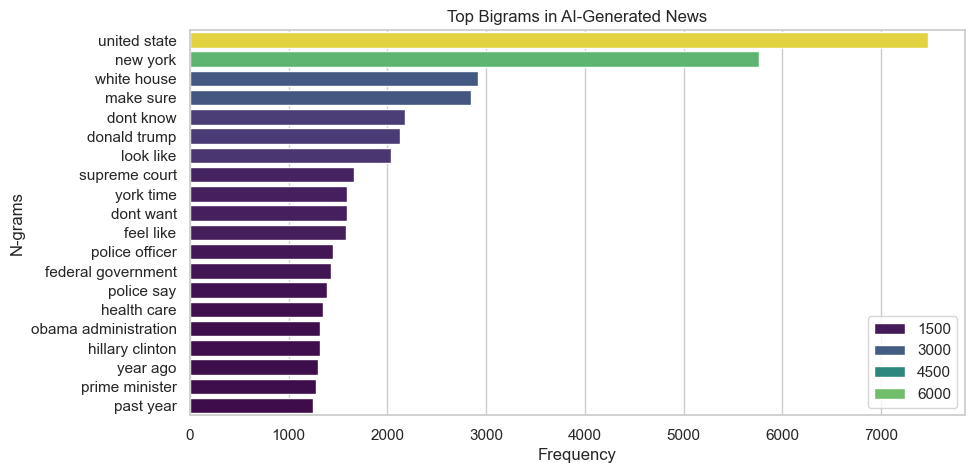

In [97]:
plot_ngrams(ai_bigrams, "Top Bigrams in AI-Generated News")

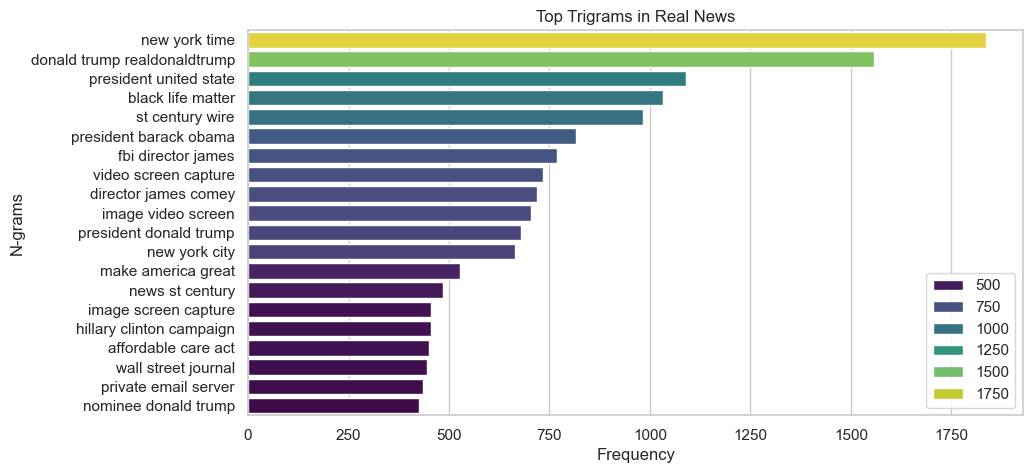

In [98]:
# Plot trigrams
plot_ngrams(real_trigrams, "Top Trigrams in Real News")

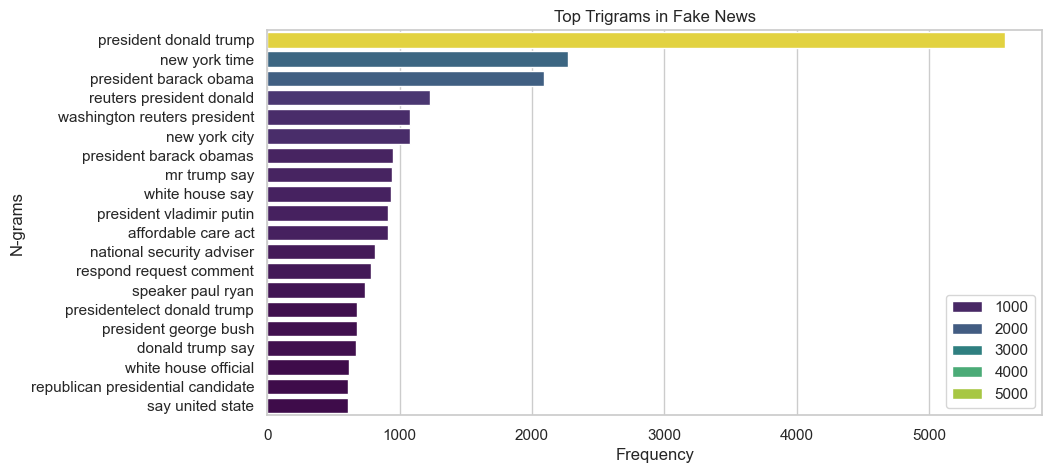

In [99]:
plot_ngrams(fake_trigrams, "Top Trigrams in Fake News")

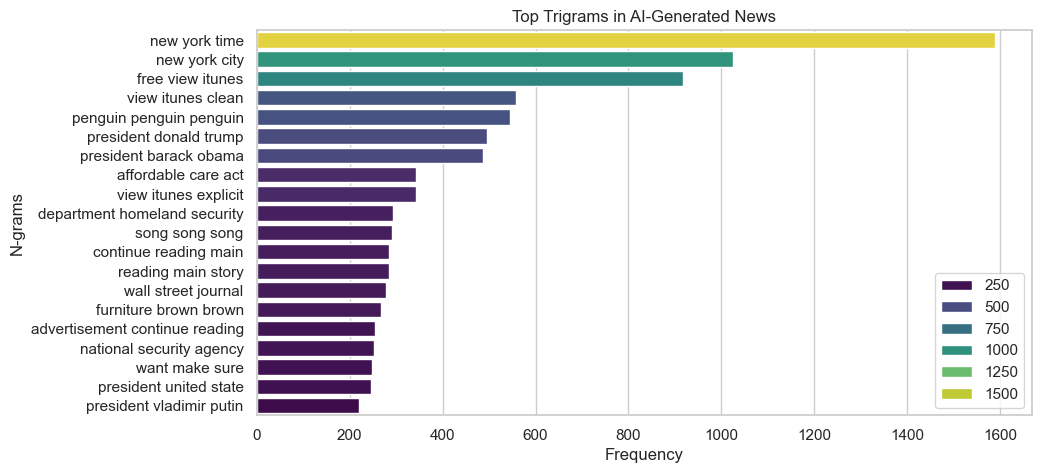

In [100]:
plot_ngrams(ai_trigrams, "Top Trigrams in AI-Generated News")

### 3.4 Sentiment Analysis

In [102]:
pip install nltk textblob

Note: you may need to restart the kernel to use updated packages.


In [103]:
from textblob import TextBlob

In [104]:
# Function to compute sentiment scores
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity  # -1 (negative) to 1 (positive)

In [105]:
# Apply sentiment analysis to each label category
real_sentiment = balanced_df[balanced_df['label'] == 'real']['text'].apply(get_sentiment)
fake_sentiment = balanced_df[balanced_df['label'] == 'fake']['text'].apply(get_sentiment)
ai_sentiment = balanced_df[balanced_df['label'] == 'AI-generated']['text'].apply(get_sentiment)

In [106]:
# Compute the mean sentiment score
sentiment_results = pd.DataFrame({
    "real": [real_sentiment.mean()],
    "fake": [fake_sentiment.mean()],
    "AI-generated": [ai_sentiment.mean()]
})

In [107]:
# Display results
print(sentiment_results)

      real      fake  AI-generated
0  0.05124  0.049893      0.091008


In [108]:
sentiment_results_long = sentiment_results.T.reset_index()
sentiment_results_long.columns = ["label", "sentiment"]

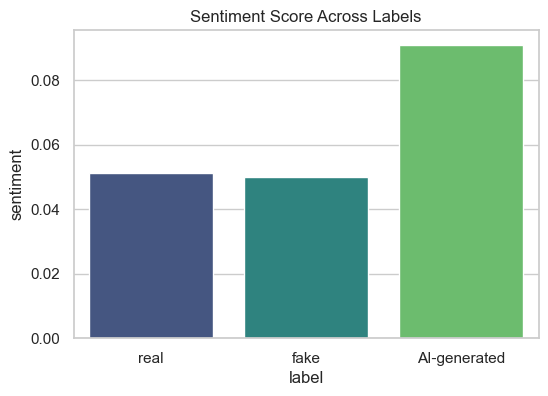

In [109]:
# Sentiment Score Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=sentiment_results_long, x="label", hue="label", y="sentiment", palette="viridis")
plt.title("Sentiment Score Across Labels")
plt.show()

## 4. Baseline Modeling
### 4.1 Data Splitting
Spliting the dataset into training, and testing sets:

In [111]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training and 20% testing.
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=42)

### 4.2 Vectorization with TF-IDF

In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [114]:
# Vectorization
vectorizer = TfidfVectorizer(max_features=10_000)
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])

If the labels are text strings ("fake", "real", "AI-generated"), they need to be encoded numerically for sklearn models. LabelEncoder or OneHotEncoder can be used.

In [116]:
# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test = le.transform(test_df['label'])

### 4.3 Training the Logistic Regression Model

In [118]:
# Model Training
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [119]:
# Validation Predictions
y_pred = lr_model.predict(X_test)

### 4.4 Logistic Regression Evaluation

In [121]:
# Print Accuracy Score
print(accuracy_score(y_test, y_pred))

0.8982078853046594


In [122]:
# Evaluation
print("Validation Metrics:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Validation Metrics:
              precision    recall  f1-score   support

AI-generated       0.88      0.89      0.89      5580
        fake       0.91      0.91      0.91      5580
        real       0.90      0.90      0.90      5580

    accuracy                           0.90     16740
   macro avg       0.90      0.90      0.90     16740
weighted avg       0.90      0.90      0.90     16740



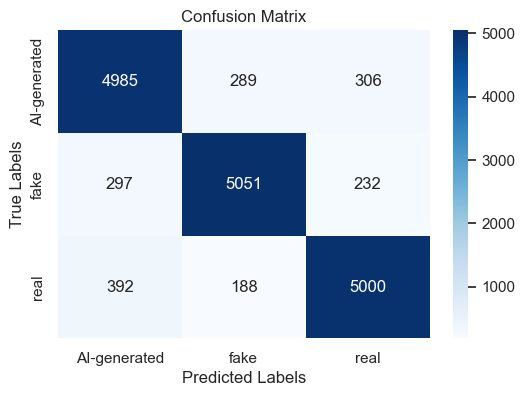

In [123]:
from sklearn.metrics import confusion_matrix

# Define the label names
labels = le.classes_

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## 6. Investigating Different Methodologies
### 6.1 SVM

In [125]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', class_weight='balanced')
svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear')

### 6.2 SVM Evaluation

In [127]:
# Validation Predictions
y_pred = svm_model.predict(X_test)

In [128]:
# Print Accuracy Score
print(accuracy_score(y_test, y_pred))

0.901194743130227


In [129]:
# Evaluation
print("Validation Metrics:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Validation Metrics:
              precision    recall  f1-score   support

AI-generated       0.88      0.90      0.89      5580
        fake       0.92      0.91      0.91      5580
        real       0.91      0.89      0.90      5580

    accuracy                           0.90     16740
   macro avg       0.90      0.90      0.90     16740
weighted avg       0.90      0.90      0.90     16740



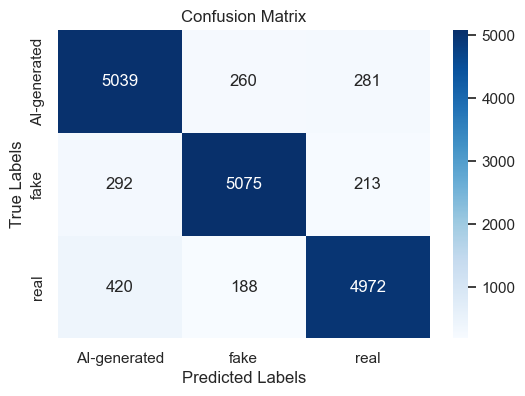

In [130]:
from sklearn.metrics import confusion_matrix

# Define the label names
labels = le.classes_

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### 6.3 Random Forest Classifier

In [132]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rfc_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

### 6.4 Random Forest Classifier Evaluation

In [134]:
# Validation Predictions
y_pred = rfc_model.predict(X_test)

In [135]:
# Print Accuracy Score
print(accuracy_score(y_test, y_pred))

0.8385902031063321


In [136]:
# Evaluation
print("Validation Metrics:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Validation Metrics:
              precision    recall  f1-score   support

AI-generated       0.81      0.82      0.81      5580
        fake       0.84      0.86      0.85      5580
        real       0.87      0.84      0.85      5580

    accuracy                           0.84     16740
   macro avg       0.84      0.84      0.84     16740
weighted avg       0.84      0.84      0.84     16740



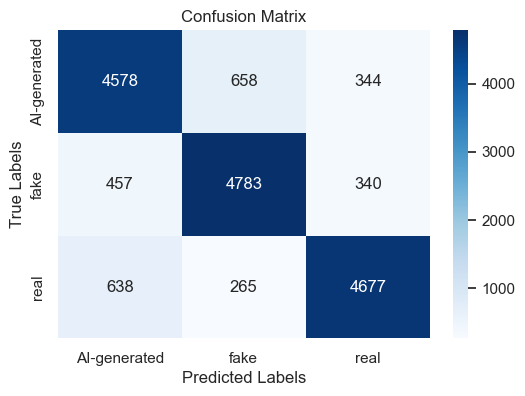

In [137]:
from sklearn.metrics import confusion_matrix

# Define the label names
labels = le.classes_

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### 6.5 FastText Embeddings

In [139]:
from gensim.models import KeyedVectors

In [140]:
# Download embedding file from Google Drive
file_id = "1rKbd3POp3F1KOgVBqUS0fJoDJdCNrYsx"
destination = "embeddings/wiki-news-300d-1M-subword.vec"

gdown.download(f"https://drive.google.com/uc?id={file_id}", destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1rKbd3POp3F1KOgVBqUS0fJoDJdCNrYsx
From (redirected): https://drive.google.com/uc?id=1rKbd3POp3F1KOgVBqUS0fJoDJdCNrYsx&confirm=t&uuid=6343d3e0-fd2f-4869-aed2-8abd7e20afb1
To: /Users/yassu/Desktop/FP_Fake_News/embeddings/wiki-news-300d-1M-subword.vec
100%|████████████████████████████████████████████| 2.26G/2.26G [04:00<00:00, 9.37MB/s]


'embeddings/wiki-news-300d-1M-subword.vec'

In [141]:
# Load the FastText word vectors (non-binary format)
fasttext_embedding_path = "embeddings/wiki-news-300d-1M-subword.vec"
word_vectors = KeyedVectors.load_word2vec_format(fasttext_embedding_path, binary=False)

In [142]:
# Test the embedding with a word
word = "news"
if word in word_vectors:
    print(f"Vector for '{word}':\n", word_vectors[word])
else:
    print(f"'{word}' not found in vocabulary")

Vector for 'news':
 [ 0.0307 -0.0526  0.0152  0.0368 -0.0101 -0.0243  0.0263 -0.0694  0.0633
  0.0082 -0.0216 -0.0355 -0.0078  0.0301  0.0095  0.0224  0.058  -0.0441
  0.0311 -0.0127  0.0118 -0.0128  0.0377  0.0458 -0.021  -0.008   0.006
  0.0212  0.0545 -0.024   0.0083  0.0091 -0.0415 -0.0837  0.0532  0.0064
 -0.0217  0.0311  0.0413 -0.0101 -0.0156 -0.0704  0.0042  0.0383  0.0441
  0.0225  0.0454  0.0141 -0.0124 -0.0171  0.0137 -0.0325  0.014   0.003
 -0.0032  0.0322  0.0455  0.0135 -0.0308  0.0447 -0.0557  0.0347  0.077
  0.0509  0.0443  0.0398 -0.0197  0.0636  0.0186  0.0336 -0.0149  0.0497
  0.0144 -0.0249  0.0274  0.0162  0.0231 -0.0122 -0.0077 -0.0433 -0.0037
  0.0082  0.0004  0.0153 -0.0143  0.0467 -0.0144  0.0025 -0.0031 -0.008
 -0.0105  0.0132 -0.0555 -0.0038 -0.0042  0.0193  0.0179  0.0056 -0.0011
  0.0132  0.0026 -0.0124 -0.0196  0.0033 -0.0063 -0.0536 -0.0329 -0.0196
  0.0386  0.0084 -0.0502  0.0493  0.0354  0.0498 -0.0464 -0.0243 -0.002
 -0.0031 -0.0237  0.0028 -0.0253 -0.

In [143]:
def text_to_vector(text, word_vectors, embedding_dim=300):
    words = text.split()  # Tokenize text into words
    word_vecs = [word_vectors[word] for word in words if word in word_vectors]  # Keep only known words
    
    if len(word_vecs) == 0:
        return np.zeros(embedding_dim)  # If no known words, return zero vector
    
    return np.mean(word_vecs, axis=0)  # Compute mean of word vectors

In [144]:
# Convert train and test text into FastText embeddings
X_train_embeddings = np.array([text_to_vector(text, word_vectors) for text in train_df['text']])
X_test_embeddings = np.array([text_to_vector(text, word_vectors) for text in test_df['text']])

In [145]:
# Encode labels (same as before)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test = le.transform(test_df['label'])

## 7. Deep Learning Models 
### 7.1 Data Check & Prep for Model Training

In [147]:
print("Training Samples:", len(train_df))

Training Samples: 66957


In [148]:
print("Testing Samples:", len(test_df))

Testing Samples: 16740


In [149]:
print("Class Distribution:\n", train_df['label'].value_counts())

Class Distribution:
 label
real            22319
fake            22319
AI-generated    22319
Name: count, dtype: int64


In [150]:
print("Example raw text:", train_df['text'].iloc[0])

Example raw text: sen elizabeth warren dmass object serious concern white house due potential presidential challenger despite fact say runthe white house team republican national committee rnc dig whatever warren whatever fabricate circulate condemn memo reportersmeanwhile aide white house keep tab warren criticism trump use medium aggressively hit back last month hill publish senator criticism america large nonnuclear bomb drop afghanistan white house quickly scramble rebuttal unusually high level concern one senator somebody probably heart mind liberal activist leader party voice carry weight respond say white house official wish remain anonymousin effort put senator trump brought back favorite offensive warren insult last month refer pocahontas deliver speech national rifle associate feel next election go swamp candidate say trump may pocahontas remember many see warren likely presidential candidate trump find legitimate fault adversary cowardly resort racial insult attempt make loo

### 7.2 RNNs BiLSTM with FastText Embeddings

In [152]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, BatchNormalization, Dropout, Dense, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.backend import clear_session

In [153]:
# Clear previous models & TensorFlow session to start fresh
clear_session()

In [154]:
# Hyperparameters
embedding_dim = 300
vocab_size = 75000
max_len = 700

In [155]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text'])
word_index = tokenizer.word_index

In [156]:
# Load FastText Embeddings & Align with Tokenizer
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
for word, idx in word_index.items():
    if idx <= vocab_size and word in word_vectors:
        embedding_matrix[idx] = word_vectors[word]

In [157]:
# Splitting the dataset into 80% training and 20% testing (re-defining the sets for a clean run)
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=42)

In [158]:
# Convert Text to Sequences & Pad Them
X_train_seq = tokenizer.texts_to_sequences(train_df['text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['text'])
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [159]:
# Convert Labels to One-Hot Encoding
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

In [160]:
# Define the BiLSTM Model Using `Sequential`
rnn_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size+1, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              trainable=False),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

In [161]:
# Compile Model with Correct Learning Rate
rnn_model.compile(optimizer=Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [162]:
# Define Callbacks for Training Optimization
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', 
                                 factor=0.5, 
                                 patience=2, 
                                 verbose=1, 
                                 cooldown=1, 
                                 min_lr=1e-6)

In [163]:
# Print Model Summary (Fully Built)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 700, 300)       │    22,500,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 700, 256)       │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 700, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 700, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,113,935 (88.17 MB)

 Trainable params: 612,867 (2.34 MB)

 Non-trainable params: 22,501,068 (85.83 MB)

In [164]:
# Train the Model
history = rnn_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1418s 1s/step - accuracy: 0.4420 - loss: 1.2629 - val_accuracy: 0.7010 - val_loss: 0.7245 - learning_rate: 1.0000e-05
Epoch 2/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1438s 1s/step - accuracy: 0.6783 - loss: 0.7760 - val_accuracy: 0.7382 - val_loss: 0.6348 - learning_rate: 1.0000e-05
Epoch 3/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1460s 1s/step - accuracy: 0.7273 - loss: 0.6686 - val_accuracy: 0.7601 - val_loss: 0.5938 - learning_rate: 1.0000e-05
Epoch 4/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1456s 1s/step - accuracy: 0.7501 - loss: 0.6275 - val_accuracy: 0.7752 - val_loss: 0.5592 - learning_rate: 1.0000e-05
Epoch 5/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1448s 1s/step - accuracy: 0.7642 - loss: 0.5891 - val_accuracy: 0.7870 - val_loss: 0.5331 - learning_rate: 1.0000e-05
Epoch 6/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 1453s 1s/step - accuracy: 0.7841 - loss: 0.5512 - val_accuracy: 0.7927 - val_loss: 0.5259 - learning_rate: 1.0000e-05
Epoch 7/20
1047/1047 ━━━━━━━━━━━━━━━━━━━

### 7.3 BiLSTM Evaluation

In [166]:
# Print test loss & accuracy
test_loss, test_accuracy = rnn_model.evaluate(X_test_pad, y_test_cat)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

524/524 ━━━━━━━━━━━━━━━━━━━━ 172s 329ms/step - accuracy: 0.8497 - loss: 0.3999
Test Loss: 0.3985
Test Accuracy: 0.8492


In [167]:
# Get model predictions (raw probabilities)
y_pred_prob = rnn_model.predict(X_test_pad)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)  # Convert one-hot encoding back to labels

524/524 ━━━━━━━━━━━━━━━━━━━━ 171s 326ms/step


In [168]:
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["AI-generated", "Fake", "Real"]))

Classification Report:
               precision    recall  f1-score   support

AI-generated       0.86      0.84      0.85      5580
        Fake       0.87      0.83      0.85      5580
        Real       0.82      0.88      0.85      5580

    accuracy                           0.85     16740
   macro avg       0.85      0.85      0.85     16740
weighted avg       0.85      0.85      0.85     16740



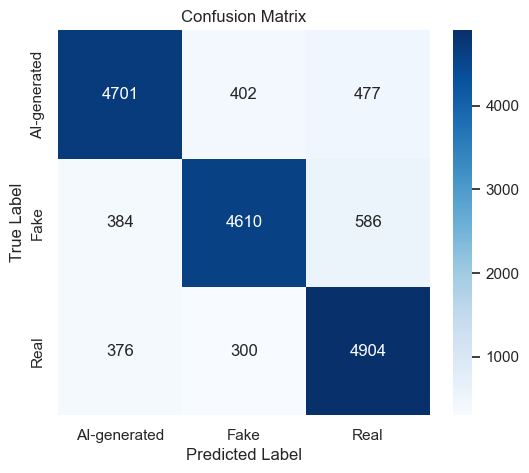

In [169]:
# Define the label names
labels = ["AI-generated", "Fake", "Real"]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## 8. Transformer Models 
### 8.1 RoBERTa
📌 Final Answer: What Embedding Should You Use? <br>
✅ For RoBERTa & DistilBERT, do NOT use FastText, Word2Vec, or GloVe.<br>
✅ Instead, use their built-in tokenizers (RobertaTokenizer or DistilBertTokenizer).<br>
✅ Pretrained Transformer models already generate contextualized embeddings, so no separate embedding layer is needed.

In [171]:
pip install transformers datasets torch tensorflow accelerate scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [172]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [173]:
rm -rf logs/ roberta_results/ roberta_fake_news/

In [174]:
rm -rf ~/.cache/huggingface/

In [175]:
balanced_df.head()

,text,label
0,leave reply michael forrester every cause dise...,real
1,use tell every night election would sleep floo...,AI-generated
2,rudy hilderbrand former general manager united...,AI-generated
3,article london review book mark bowden detail ...,AI-generated
4,bev harris black box voting unearthed devious ...,real


In [176]:
# Splitting the dataset into 80% training and 20% testing (re-defining the sets for a clean run)
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=42)

In [177]:
train_df.head()

,text,label
60311,sen elizabeth warren dmass object serious conc...,real
45598,washington reuters detailed version president ...,fake
75082,reuters proposal u republican repeal restrict ...,fake
30852,nairobi reuters kenyan president uhuru kenyatt...,fake
67703,surprise online publication would use term gay...,AI-generated


In [178]:
test_df.head()

,text,label
49864,thanks aggressive push stream service like net...,fake
9769,look around world today likely find vast varie...,AI-generated
54932,man two face one probably conman liar man behi...,AI-generated
13307,question whoopi goldberg talented actress abil...,real
52381,february common stereotype food stamp recipien...,real


In [179]:
# Encode Labels (Convert 'Real', 'Fake', 'AI-generated' to numbers)
label_mapping = {'AI-generated': 0, 'fake': 1, 'real': 2}
train_df['label'] = train_df['label'].map(label_mapping)
test_df['label'] = test_df['label'].map(label_mapping)

In [180]:
# Load RoBERTa Tokenizer
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [181]:
# Tokenization Function
def tokenize_function(batch):
    return roberta_tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

In [182]:
# Convert train_df & test_df to Hugging Face Dataset Format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [183]:
# Tokenize Text
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/66957 [00:00<?, ? examples/s]

Map:   0%|          | 0/16740 [00:00<?, ? examples/s]

In [184]:
train_df.head()

,text,label
60311,sen elizabeth warren dmass object serious conc...,2
45598,washington reuters detailed version president ...,1
75082,reuters proposal u republican repeal restrict ...,1
30852,nairobi reuters kenyan president uhuru kenyatt...,1
67703,surprise online publication would use term gay...,0


In [185]:
# Remove extra columns (only keep 'input_ids', 'attention_mask', and 'label')
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

In [186]:
# Load RoBERTa Model for Classification (3 classes: AI-generated, Fake, Real)
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3) 

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [187]:
training_args = TrainingArguments(
    output_dir="./roberta_results",  # Save model checkpoints
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",  # Save best model per epoch
    save_total_limit=2,  # Keep only 2 checkpoints
    learning_rate=2e-5,  # Optimized LR for Transformers
    per_device_train_batch_size=32,  # Balanced batch size for performance
    per_device_eval_batch_size=32,  # Same for evaluation
    num_train_epochs=3,  # Enough training without overfitting
    weight_decay=0.01,  # Regularization
    load_best_model_at_end=True,  # Automatically load the best model
    logging_dir="./logs",  # For TensorBoard
    logging_steps=100,  # Log every 100 steps
    report_to="none",  # Avoids WandB errors if not used
)

In [188]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=1  # Stop training if validation loss doesn't improve after 1 epoch
)

In [189]:
trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    callbacks=[early_stopping]  # Add Early Stopping to avoid overfitting
)

In [190]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.147000,0.279422
2,0.093800,0.141125
3,0.057500,0.185492


TrainOutput(global_step=6279, training_loss=0.12385664785111439, metrics={'train_runtime': 20751.6384, 'train_samples_per_second': 9.68, 'train_steps_per_second': 0.303, 'total_flos': 5.285185533244109e+16, 'train_loss': 0.12385664785111439, 'epoch': 3.0})

### 8.2 RoBERTa Evaluation

In [192]:
# Evaluate the model
eval_results = trainer.evaluate()
print(f"Validation Results: {eval_results}")

Validation Results: {'eval_loss': 0.1411254107952118, 'eval_runtime': 526.3537, 'eval_samples_per_second': 31.804, 'eval_steps_per_second': 0.996, 'epoch': 3.0}


In [193]:
# Get predictions and true labels
roberta_predictions = trainer.predict(test_dataset)
roberta_pred_labels = roberta_predictions.predictions.argmax(axis=-1)
roberta_true_labels = test_dataset["label"]

In [194]:
print("Accuracy:", accuracy_score(roberta_true_labels, roberta_pred_labels))

Accuracy: 0.9640979689366787


In [195]:
print("Classification Report:\n", classification_report(roberta_true_labels, roberta_pred_labels, target_names=["AI-generated", "Fake", "Real"]))

Classification Report:
               precision    recall  f1-score   support

AI-generated       0.93      0.99      0.96      5580
        Fake       0.99      0.94      0.96      5580
        Real       0.98      0.97      0.97      5580

    accuracy                           0.96     16740
   macro avg       0.97      0.96      0.96     16740
weighted avg       0.97      0.96      0.96     16740



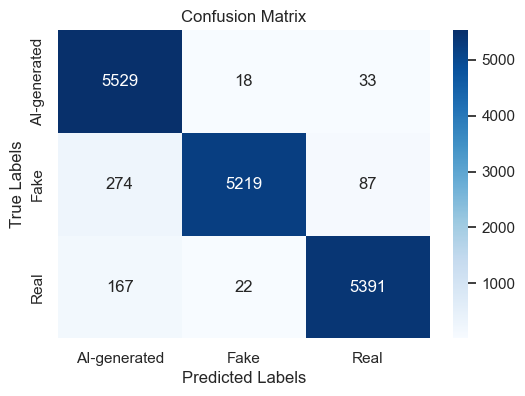

In [196]:
# Define the label names
labels = ["AI-generated", "Fake", "Real"]

# Compute confusion matrix
cm = confusion_matrix(roberta_true_labels, roberta_pred_labels)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [197]:
# Save model and tokenizer
roberta_model.save_pretrained("roberta_fake_news")
roberta_tokenizer.save_pretrained("roberta_fake_news")

('roberta_fake_news/tokenizer_config.json',
 'roberta_fake_news/special_tokens_map.json',
 'roberta_fake_news/vocab.json',
 'roberta_fake_news/merges.txt',
 'roberta_fake_news/added_tokens.json')

### 8.3 DistilBERT

In [199]:
# Splitting the dataset into 80% training and 20% testing (re-defining the sets for a clean run)
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=42)

In [200]:
rm -rf ~/.cache/huggingface/

In [201]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load tokenizer and model
distilbert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [202]:
balanced_df.head()

,text,label
0,leave reply michael forrester every cause dise...,real
1,use tell every night election would sleep floo...,AI-generated
2,rudy hilderbrand former general manager united...,AI-generated
3,article london review book mark bowden detail ...,AI-generated
4,bev harris black box voting unearthed devious ...,real


In [203]:
train_df.head()

,text,label
60311,sen elizabeth warren dmass object serious conc...,real
45598,washington reuters detailed version president ...,fake
75082,reuters proposal u republican repeal restrict ...,fake
30852,nairobi reuters kenyan president uhuru kenyatt...,fake
67703,surprise online publication would use term gay...,AI-generated


In [204]:
test_df.head()

,text,label
49864,thanks aggressive push stream service like net...,fake
9769,look around world today likely find vast varie...,AI-generated
54932,man two face one probably conman liar man behi...,AI-generated
13307,question whoopi goldberg talented actress abil...,real
52381,february common stereotype food stamp recipien...,real


In [205]:
# Encode Labels (Convert 'Real', 'Fake', 'AI-generated' to numbers)
label_mapping = {'AI-generated': 0, 'fake': 1, 'real': 2}
train_df['label'] = train_df['label'].map(label_mapping)
test_df['label'] = test_df['label'].map(label_mapping)

In [206]:
# Tokenization Function
def tokenize_function(batch):
    return distilbert_tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

In [207]:
# Convert train_df & test_df to Hugging Face Dataset Format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [208]:
# Tokenize Text
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/66957 [00:00<?, ? examples/s]

Map:   0%|          | 0/16740 [00:00<?, ? examples/s]

In [209]:
train_df.head()

,text,label
60311,sen elizabeth warren dmass object serious conc...,2
45598,washington reuters detailed version president ...,1
75082,reuters proposal u republican repeal restrict ...,1
30852,nairobi reuters kenyan president uhuru kenyatt...,1
67703,surprise online publication would use term gay...,0


In [210]:
# Remove extra columns (only keep 'input_ids', 'attention_mask', and 'label')
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

In [211]:
training_args = TrainingArguments(
    output_dir="./distilbert_results",  # Save model checkpoints
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",  # Save best model per epoch
    save_total_limit=2,  # Keep only 2 checkpoints
    learning_rate=2e-5,  # Optimized LR for Transformers
    per_device_train_batch_size=32,  # Balanced batch size for performance
    per_device_eval_batch_size=32,  # Same for evaluation
    num_train_epochs=3,  # Enough training without overfitting
    weight_decay=0.01,  # Regularization
    load_best_model_at_end=True,  # Automatically load the best model
    logging_dir="./logs",  # For TensorBoard
    logging_steps=100,  # Log every 100 steps
    report_to="none",  # Avoids WandB errors if not used
)

In [212]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=1  # Stop training if validation loss doesn't improve after 1 epoch
)

In [213]:
trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    callbacks=[early_stopping]  # Add Early Stopping to avoid overfitting
)

In [214]:
# Train Model
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.153700,0.126228
2,0.088000,0.112147
3,0.042800,0.136312


TrainOutput(global_step=6279, training_loss=0.1189033210913568, metrics={'train_runtime': 9803.2588, 'train_samples_per_second': 20.49, 'train_steps_per_second': 0.641, 'total_flos': 2.6609333366651904e+16, 'train_loss': 0.1189033210913568, 'epoch': 3.0})

### 8.4 DistilBERT Evaluation

In [216]:
# Evaluate the model
eval_results = trainer.evaluate()
print(f"Validation Results: {eval_results}")

Validation Results: {'eval_loss': 0.11214732378721237, 'eval_runtime': 267.6141, 'eval_samples_per_second': 62.553, 'eval_steps_per_second': 1.958, 'epoch': 3.0}


In [217]:
# Get predictions and true labels
distilbert_predictions = trainer.predict(test_dataset)
distilbert_pred_labels = distilbert_predictions.predictions.argmax(axis=-1)
distilbert_true_labels = test_dataset["label"]

In [218]:
print("Accuracy:", accuracy_score(distilbert_true_labels, distilbert_pred_labels))

Accuracy: 0.9687574671445639


In [219]:
print("Classification Report:\n", classification_report(distilbert_true_labels, distilbert_pred_labels, target_names=["AI-generated", "Fake", "Real"]))

Classification Report:
               precision    recall  f1-score   support

AI-generated       0.95      0.98      0.96      5580
        Fake       0.98      0.96      0.97      5580
        Real       0.98      0.97      0.97      5580

    accuracy                           0.97     16740
   macro avg       0.97      0.97      0.97     16740
weighted avg       0.97      0.97      0.97     16740



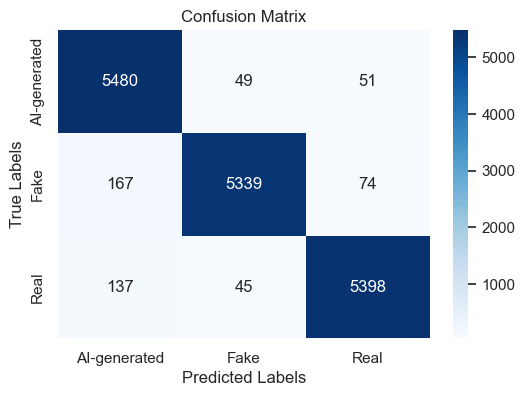

In [220]:
# Define the label names
labels = ["AI-generated", "Fake", "Real"]

# Compute confusion matrix
cm = confusion_matrix(distilbert_true_labels, distilbert_pred_labels)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [221]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from scipy.special import softmax

# Extract logits from predictions
logits = distilbert_predictions.predictions

# Convert logits to probabilities using softmax
probabilities = softmax(logits, axis=-1)

In [222]:
from sklearn.preprocessing import label_binarize

# Assuming `distilbert_true_labels` contains integer class labels
num_classes = len(np.unique(distilbert_true_labels))
true_labels_one_hot = label_binarize(distilbert_true_labels, classes=np.arange(num_classes))

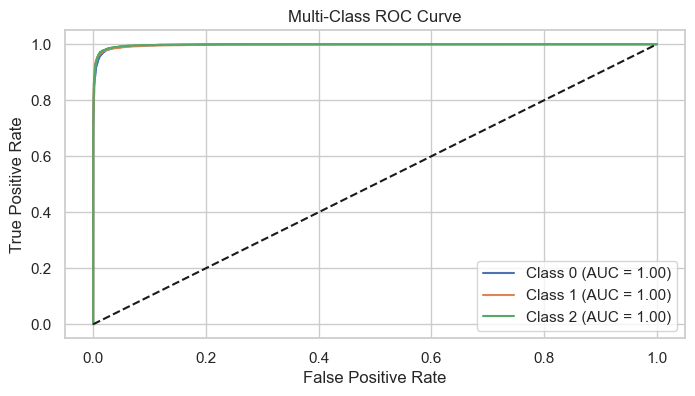

In [223]:
# Plot ROC for each class
plt.figure(figsize=(8, 4))
for i in range(num_classes):
    # Compute False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], probabilities[:, i])
    # Compute AUC for the current class
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve for the current class with its AUC value in the legend
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line for random guessing
plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

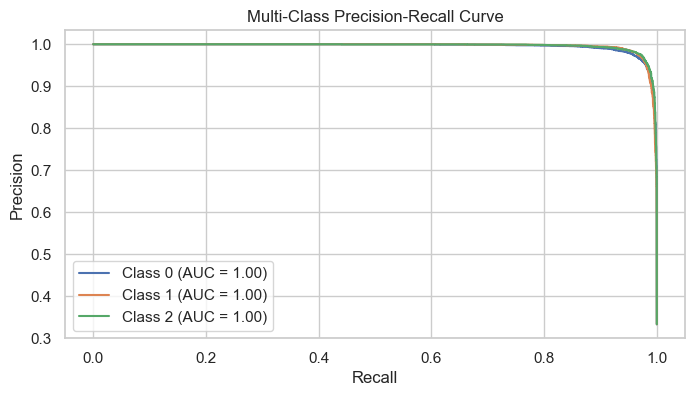

In [224]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Create a new figure for the precision-recall curves
plt.figure(figsize=(8, 4))

# Plot the precision-recall curve for each class
for i in range(num_classes):
    # Compute precision, recall, and thresholds for class i
    precision, recall, _ = precision_recall_curve(true_labels_one_hot[:, i], probabilities[:, i])
    
    # Compute AUC for the precision-recall curve
    pr_auc = auc(recall, precision)
    
    # Plot the precision-recall curve for the current class
    plt.plot(recall, precision, label=f"Class {i} (AUC = {pr_auc:.2f})")

# Add plot title and axis labels
plt.title("Multi-Class Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

# Display legend for class labels
plt.legend()

# Show the plot
plt.show()


In [225]:
# Save model and tokenizer
distilbert_model.save_pretrained("distilbert_fake_news")
distilbert_tokenizer.save_pretrained("distilbert_fake_news")

('distilbert_fake_news/tokenizer_config.json',
 'distilbert_fake_news/special_tokens_map.json',
 'distilbert_fake_news/vocab.txt',
 'distilbert_fake_news/added_tokens.json')

## 9. Cross-Validation 
### 9.1 Cross-Validation with StratifiedKFold
Before deploying, we need to verify that DistilBERT performs consistently across different subsets of data.

In [698]:
# Splitting the dataset into 80% training and 20% testing (re-defining the sets for a clean run)
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df['label'], random_state=42)

In [704]:
from sklearn.model_selection import StratifiedKFold

# Set up 5-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
cv_accuracies = []
cv_f1_scores = []

In [706]:
for fold, (train_idx, val_idx) in enumerate(kf.split(train_df['text'], train_df['label'])):
    print(f"Training Fold {fold+1}/5...")

    # Load DistilBERT model & tokenizer
    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    
    # Create fold-specific train & val sets
    train_texts, val_texts = train_df['text'].iloc[train_idx], train_df['text'].iloc[val_idx]
    train_labels, val_labels = train_df['label'].iloc[train_idx], train_df['label'].iloc[val_idx]

    # Encode labels as integers
    label_map = {"AI-generated": 0, "fake": 1, "real": 2}
    train_labels = train_labels.map(label_map).tolist()
    val_labels = val_labels.map(label_map).tolist()

    # Tokenize
    train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=512)
    val_encodings = tokenizer(val_texts.tolist(), truncation=True, padding=True, max_length=512)

    # Convert to Hugging Face Dataset Format
    train_dataset = Dataset.from_dict({
        "input_ids": train_encodings["input_ids"], 
        "attention_mask": train_encodings["attention_mask"],  # Include attention masks
        "label": train_labels
    })
    
    val_dataset = Dataset.from_dict({
        "input_ids": val_encodings["input_ids"], 
        "attention_mask": val_encodings["attention_mask"], 
        "label": val_labels
    })
    
    # Define Training Arguments
    training_args = TrainingArguments(
        output_dir=f"./results_fold{fold+1}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="./logs",
    )
    
    # Define trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )
    
    # Train model
    trainer.train()
    
    # Evaluate model
    eval_results = trainer.evaluate()
    cv_accuracies.append(eval_results["eval_accuracy"])
    cv_f1_scores.append(eval_results["eval_f1"])

Training Fold 1/5...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.161600,0.201227,0.935857,0.941403,0.935857,0.936287
2,0.093400,0.127537,0.963262,0.963565,0.963262,0.963277
3,0.039400,0.159622,0.962366,0.963115,0.962366,0.962423


Training Fold 2/5...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.159100,0.141521,0.953402,0.955193,0.953402,0.953568
2,0.091800,0.128867,0.961392,0.962509,0.961392,0.961483
3,0.042500,0.140343,0.966246,0.966747,0.966246,0.966292


Training Fold 5/5...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.163600,0.117931,0.960720,0.960852,0.960720,0.960723
2,0.095100,0.112536,0.966097,0.966231,0.966097,0.966111
3,0.050300,0.141183,0.965350,0.966107,0.965350,0.965416


### 9.2 StratifiedKFold Results

In [707]:
# Print Cross-Validation Results
print(f"Average Accuracy across folds: {np.mean(cv_accuracies):.4f}")
print(f"Average F1-score across folds: {np.mean(cv_f1_scores):.4f}")

Average Accuracy across folds: 0.9642
Average F1-score across folds: 0.9642


## 10. Cross-Dataset Validation
### 10.1 Loading the Datasets

In [1238]:
# Load the real or fake news Dataset
# news_df = pd.read_csv("data/fake_or_real_news.csv")

In [1240]:
# Download dataset from Google Drive
file_id = "1KSIItFi66IgPCmqqkduKHWVxt3pntj2I"
destination = "g_data/fake_or_real_news.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", destination, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1KSIItFi66IgPCmqqkduKHWVxt3pntj2I
To: /Users/yassu/Desktop/FP_Fake_News/g_data/fake_or_real_news.csv
100%|██████████████████████████████████████| 30.7M/30.7M [00:04<00:00, 7.11MB/s]


'g_data/fake_or_real_news.csv'

In [1241]:
news_df = pd.read_csv(destination)

In [1242]:
news_df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [859]:
news_df.tail()

,Unnamed: 0,title,text,label
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL
6334,4330,Jeb Bush Is Suddenly Attacking Trump. Here's W...,Jeb Bush Is Suddenly Attacking Trump. Here's W...,REAL


In [1246]:
# Load the AI-generated news Dataset
# ai_df = pd.read_csv("data/ai_generated_news.csv")

In [1248]:
# Download dataset from Google Drive
file_id = "1d85UoP_1633oizycjs9o01q1FgjA633x"
destination = "g_data/ai_generated_news.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", destination, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1d85UoP_1633oizycjs9o01q1FgjA633x
To: /Users/yassu/Desktop/FP_Fake_News/g_data/ai_generated_news.csv
100%|██████████████████████████████████████| 3.67M/3.67M [00:00<00:00, 4.12MB/s]


'g_data/ai_generated_news.csv'

In [1249]:
ai_df = pd.read_csv(destination)

In [1250]:
ai_df.head()

,text,label
0,The landscape of World News is undergoing rapi...,AI-generated
1,The landscape of Sports is undergoing rapid tr...,AI-generated
2,"In a recent turn of events, Environment has be...",AI-generated
3,"In a recent turn of events, Science has become...",AI-generated
4,The landscape of Education is undergoing rapid...,AI-generated


### 10.2 Pre-processing the Fake & Real News Validation Dataset

In [867]:
# Keep only required columns
news_df = news_df[["text", "label"]]

In [869]:
# Shuffle Dataset
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [871]:
news_df.isnull().sum()

text     0
label    0
dtype: int64

In [873]:
news_df = news_df.drop_duplicates(subset='text').reset_index(drop=True)

In [875]:
news_df = news_df.dropna(subset=['text'])

In [877]:
news_df.head()

,text,label
0,Will Trump pull a Brexit times ten? What would...,FAKE
1,Clintons Are Under Multiple FBI Investigations...,FAKE
2,Dispatches from Eric Zuesse This piece is cros...,FAKE
3,Print \n[Ed. – Every now and then the facade c...,FAKE
4,Nanny In Jail After Force Feeding Baby To Deat...,FAKE


In [879]:
# Apply clean_text function to clean the dataframe
news_df['cleaned_text'] = news_df['text'].apply(clean_text)

In [880]:
news_df.head()

,text,label,cleaned_text
0,Will Trump pull a Brexit times ten? What would...,FAKE,trump pull brexit time ten would take beyond w...
1,Clintons Are Under Multiple FBI Investigations...,FAKE,clinton multiple fbi investigation agent stymi...
2,Dispatches from Eric Zuesse This piece is cros...,FAKE,dispatch eric zuesse piece crossposted strateg...
3,Print \n[Ed. – Every now and then the facade c...,FAKE,print ed every facade crack somebody asks ques...
4,Nanny In Jail After Force Feeding Baby To Deat...,FAKE,nanny jail force feed baby death share ike mcl...


In [881]:
news_df.tail()

,text,label,cleaned_text
6055,What happened was less a debate among contende...,REAL,happen less debate among contender showdown ca...
6056,"Clinton, FBIGate and the true depth of the Oba...",FAKE,clinton fbigate true depth obamageddon lady ge...
6057,"Fearing Election Day Trouble, Some US Schools ...",FAKE,fear election day trouble u school cancel clas...
6058,President Obama’s appearance at a town hall me...,REAL,president obamas appearance town hall meeting ...
6059,A man protests against international trade agr...,FAKE,man protest international trade agreement ttip...


In [882]:
news_df = news_df[["cleaned_text", "label"]]

In [883]:
news_df = news_df.rename(columns={"cleaned_text": "text"})

In [884]:
# Shuffle Dataset
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [885]:
news_df.head()

,text,label
0,enter email address receive update time publis...,FAKE
1,hillary clinton didnt take vast majority avail...,REAL
2,end last week republican debate moderator bret...,REAL
3,lot weight place libertarian expectation hope ...,REAL
4,trust one place premium revenge get even schmu...,REAL


In [886]:
news_df.tail()

,text,label
6055,email every day seem talk prison america profi...,FAKE
6056,former republican marijuanasmoking everest mou...,REAL
6057,news bulletin rita jeptoo celebrates trophy wi...,FAKE
6058,elon musk completely revolutionize energy indu...,FAKE
6059,cnn cnns state union four governor ask sunday ...,REAL


### 10.3 Pre-processing the AI-generated news validation Dataset

In [931]:
ai_df.isnull().sum()

text     0
label    0
dtype: int64

In [933]:
ai_df = ai_df.dropna(subset=['text'])

In [935]:
ai_df.head()

,text,label
0,The landscape of World News is undergoing rapi...,AI-generated
1,The landscape of Sports is undergoing rapid tr...,AI-generated
2,"In a recent turn of events, Environment has be...",AI-generated
3,"In a recent turn of events, Science has become...",AI-generated
4,The landscape of Education is undergoing rapid...,AI-generated


In [937]:
# Apply clean_text function to clean the dataframe
ai_df['cleaned_text'] = ai_df['text'].apply(clean_text)

In [938]:
ai_df.head()

,text,label,cleaned_text
0,The landscape of World News is undergoing rapi...,AI-generated,landscape world news undergo rapid transformat...
1,The landscape of Sports is undergoing rapid tr...,AI-generated,landscape sport undergo rapid transformation d...
2,"In a recent turn of events, Environment has be...",AI-generated,recent turn event environment become center di...
3,"In a recent turn of events, Science has become...",AI-generated,recent turn event science become center discus...
4,The landscape of Education is undergoing rapid...,AI-generated,landscape education undergo rapid transformati...


In [939]:
ai_df = ai_df[["cleaned_text", "label"]]

In [940]:
ai_df = ai_df.rename(columns={"cleaned_text": "text"})

In [941]:
# Shuffle Dataset
ai_df = ai_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [942]:
ai_df.head()

,text,label
0,landscape health undergo rapid transformation ...,AI-generated
1,recent turn event science become center discus...,AI-generated
2,landscape education undergo rapid transformati...,AI-generated
3,landscape politics undergo rapid transformatio...,AI-generated
4,landscape economy undergo rapid transformation...,AI-generated


In [943]:
ai_df.tail()

,text,label
2995,recent turn event health become center discuss...,AI-generated
2996,landscape environment undergo rapid transforma...,AI-generated
2997,recent turn event health become center discuss...,AI-generated
2998,recent turn event environment become center di...,AI-generated
2999,recent turn event politics become center discu...,AI-generated


### 10.4 Combining the Datasets to cover all three classes (Real, Fake & AI-generated)

In [951]:
# Combine the datasets
crossval_df = pd.concat([news_df, ai_df], ignore_index=True)

In [953]:
# Shuffle Dataset
crossval_df = crossval_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [955]:
label_map = {'AI-generated': 0, "FAKE": 1, "REAL": 2}
crossval_df['label'] = crossval_df['label'].map(label_map)

In [957]:
print(crossval_df['label'].value_counts())

label
1    3071
0    3000
2    2989
Name: count, dtype: int64


In [959]:
# Tokenize text
crossval_df_encodings = distilbert_tokenizer(crossval_df["text"].tolist(), truncation=True, padding=True, max_length=512)

In [960]:
# Convert to Hugging Face dataset format
crossval_dataset = Dataset.from_dict({"input_ids": crossval_df_encodings["input_ids"], "label": crossval_df["label"].tolist()})

In [961]:
# Load pretrained DistilBERT model
pretrained_model = DistilBertForSequenceClassification.from_pretrained("distilbert_fake_news")

In [965]:
print(crossval_df['label'].unique())  # Should print [0, 1, 2]

[1 2 0]


In [971]:
# Load training arguments (for evaluation)
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    per_device_eval_batch_size=32,  # Match training batch size
    report_to="none"
)

In [973]:
# Initialize trainer with trained model
trainer = Trainer(
    model=pretrained_model,
    args=training_args,
)

### 10.5 Cross-Dataset Model Evaluation

In [975]:
# Evaluate the model on the validation dataset
crossval_results = trainer.evaluate(crossval_dataset)

In [977]:
print(f"Validation Results: {eval_results}")

Validation Results: {'eval_loss': 0.14118312299251556, 'eval_accuracy': 0.9653498618475095, 'eval_precision': 0.9661065525009375, 'eval_recall': 0.9653498618475095, 'eval_f1': 0.9654162194673139, 'eval_runtime': 217.0244, 'eval_samples_per_second': 61.703, 'eval_steps_per_second': 1.931, 'epoch': 3.0}


In [984]:
# Print Results
print(f"Cross-Dataset Validation Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Cross-Dataset Validation Loss: {eval_results['eval_loss']:.4f}")

Cross-Dataset Validation Accuracy: 0.9653
Cross-Dataset Validation Loss: 0.1412


In [1064]:
crossval_df.head()

,text,label
0,election rape sexual assault accusation need t...,1
1,lot weight place libertarian expectation hope ...,2
2,recent turn event world news become center dis...,0
3,twitter page know black woman trump share pict...,1
4,recent turn event politics become center discu...,0


'trainer.evaluate()' directly computes accuracy and loss by comparing the model’s internal predictions to the ground truth labels. This gives a strong indication of how well the model generalizes to unseen data.

## 11. Model Loading Test

In [1057]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# Load the trained model
model_path = "distilbert_fake_news" 
model = DistilBertForSequenceClassification.from_pretrained(model_path)

# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model_path)

# Set model to evaluation mode (important for inference)
model.eval()

print("Model and tokenizer loaded successfully!")

Model and tokenizer loaded successfully!
